# Logistic Regression — End-to-End Implementation 

This notebook walks  through **Logistic Regression** from intuition to a full working pipeline.

## What you will learn
1. The **intuition** behind Logistic Regression (why we need it, how it differs from Linear Regression).
2. The **math**: sigmoid function, decision boundary, log-loss, gradient descent.
3. **End-to-end ML pipeline** on the Pima Indians Diabetes dataset:
   - Load & explore data
   - Preprocess (clean + scale)
   - Train/test split
   - Train using `scikit-learn`
   - Evaluate (accuracy, confusion matrix, ROC-AUC)
4. A **from-scratch** implementation using NumPy to truly understand what happens inside `.fit()`.
5. Compare scratch vs sklearn results.

> **Goal:** binary classification — predict whether a patient has diabetes (`1`) or not (`0`).

## 1. Intuition — Why not Linear Regression for classification?

Imagine we want to predict **diabetes (1) vs no-diabetes (0)** from `Glucose` levels.

If we use **Linear Regression**, the output is a continuous number that can be *negative* or *greater than 1*. That doesn't make sense as a probability.

We need a function that:
- Takes any real number $z \in (-\infty, +\infty)$
- Squashes it into the range $(0, 1)$ — so we can interpret it as a **probability**.

That magic function is the **Sigmoid (Logistic) function**.

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

Logistic Regression = **Linear Regression + Sigmoid + a probability threshold**.

## 2. The Math in One Glance

**Step A — Linear combination of features:**
$$z = w_1 x_1 + w_2 x_2 + \dots + w_n x_n + b = \mathbf{w}^T \mathbf{x} + b$$

**Step B — Squash to a probability:**
$$\hat{y} = \sigma(z) = \frac{1}{1+e^{-z}}$$

**Step C — Decision rule:** if $\hat{y} \geq 0.5$ predict class **1**, else class **0**.

**Step D — Loss (Binary Cross-Entropy / Log-Loss):**
$$J(\mathbf{w}, b) = -\frac{1}{m} \sum_{i=1}^{m} \Big[ y^{(i)} \log(\hat{y}^{(i)}) + (1-y^{(i)}) \log(1-\hat{y}^{(i)}) \Big]$$

**Step E — Optimise** $\mathbf{w}, b$ using **Gradient Descent**:
$$w_j := w_j - \alpha \cdot \frac{\partial J}{\partial w_j}, \quad b := b - \alpha \cdot \frac{\partial J}{\partial b}$$

Beautifully, the gradients simplify to:
$$\frac{\partial J}{\partial w_j} = \frac{1}{m}\sum_{i=1}^m (\hat{y}^{(i)} - y^{(i)}) \, x_j^{(i)}, \qquad \frac{\partial J}{\partial b} = \frac{1}{m}\sum_{i=1}^m (\hat{y}^{(i)} - y^{(i)})$$

### Visualise the Sigmoid
Let's *see* the S-shaped curve that lies at the heart of logistic regression.

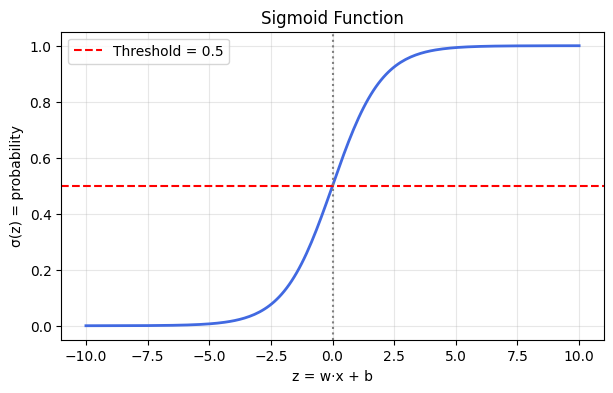

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Sigmoid function
def sigmoid(z):
    """Squashes any real number into the range (0, 1)."""
    return 1 / (1 + np.exp(-z))

# Plot it
z = np.linspace(-10, 10, 200)
plt.figure(figsize=(7, 4))
plt.plot(z, sigmoid(z), color="royalblue", linewidth=2)
plt.axhline(0.5, color="red", linestyle="--", label="Threshold = 0.5")
plt.axvline(0, color="gray", linestyle=":")
plt.title("Sigmoid Function")
plt.xlabel("z = w·x + b")
plt.ylabel("σ(z) = probability")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 3. End-to-End Pipeline — Step 1: Imports

We import everything we need: data handling (`pandas`, `numpy`), visualisation (`matplotlib`, `seaborn`), and ML utilities from `scikit-learn`.

In [2]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# scikit-learn utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
)

# Display settings
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

# Reproducibility
RANDOM_STATE = 42

## Step 2: Load the Dataset
We use the **Pima Indians Diabetes** dataset. Each row is a patient; the `Outcome` column is `1` (diabetic) or `0` (not diabetic).

In [3]:
# Path to the dataset (relative to project root)
DATA_PATH = "../../datasets/diabetes.csv"

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()

Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Step 3: Quick Exploratory Data Analysis (EDA)
Before modelling, always *peek* at the data — understand types, missing values, and the target balance.

In [4]:
# Datatypes & non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
# Statistical summary
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


C:\Users\veguntur\AppData\Local\Temp\ipykernel_26224\1916854015.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="Outcome", data=df, palette="Set2")


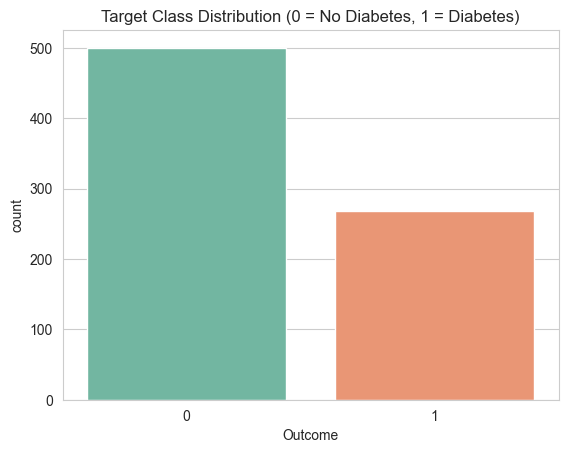

Outcome
0    0.651
1    0.349
Name: proportion, dtype: float64


In [6]:
# Class balance — how many diabetic vs non-diabetic?
ax = sns.countplot(x="Outcome", data=df, palette="Set2")
ax.set_title("Target Class Distribution (0 = No Diabetes, 1 = Diabetes)")
plt.show()

print(df["Outcome"].value_counts(normalize=True).round(3))

## Step 4: Clean the Data
In this dataset, columns like `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI` cannot realistically be **0** — those zeros are actually **missing values** in disguise.

We replace those zeros with the **median** of their column (a simple, robust imputation strategy).

In [7]:
def clean_zeros_with_median(dataframe, columns):
    """Replace 0 values in given columns with the column's median."""
    df_clean = dataframe.copy()
    for col in columns:
        median_val = df_clean.loc[df_clean[col] != 0, col].median()
        df_clean[col] = df_clean[col].replace(0, median_val)
    return df_clean

cols_with_invalid_zeros = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
df = clean_zeros_with_median(df, cols_with_invalid_zeros)
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.386719,29.108073,140.671875,32.455208,0.471876,33.240885,0.348958
std,3.369578,30.438286,12.096642,8.791221,86.383060,6.875177,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,121.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,125.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Step 5: Separate Features (X) and Target (y)

In [8]:
X = df.drop(columns=["Outcome"])  # input features
y = df["Outcome"]                  # target label (0 / 1)

print("Features shape:", X.shape)
print("Target shape  :", y.shape)

Features shape: (768, 8)
Target shape  : (768,)


## Step 6: Train / Test Split
We hold out **20%** of the data to evaluate the model on *unseen* samples. `stratify=y` keeps the class ratio identical in train and test sets.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (614, 8) | Test: (154, 8)


## Step 7: Feature Scaling
Logistic Regression uses gradient descent. Features on **wildly different scales** (e.g. `Insulin` 0–800 vs `DiabetesPedigreeFunction` 0–2.5) make optimisation slow and unstable.

We standardise features → mean 0, std 1.

> **Important:** fit the scaler on **train only**, then transform both sets — this avoids *data leakage*.

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

## Step 8: Train Logistic Regression (scikit-learn)
Just two lines — create the model, call `.fit()`.

In [11]:
model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
model.fit(X_train_scaled, y_train)

print("Learned weights (w):", np.round(model.coef_[0], 3))
print("Learned bias    (b):", round(model.intercept_[0], 3))

Learned weights (w): [ 0.378  1.183 -0.044  0.028 -0.066  0.689  0.233  0.148]
Learned bias    (b): -0.872


### Interpreting the weights
A **positive weight** means: as that feature increases, the probability of diabetes increases. A **negative weight** means the opposite. The magnitude tells you the *strength* of influence (because we standardised the features, magnitudes are directly comparable).

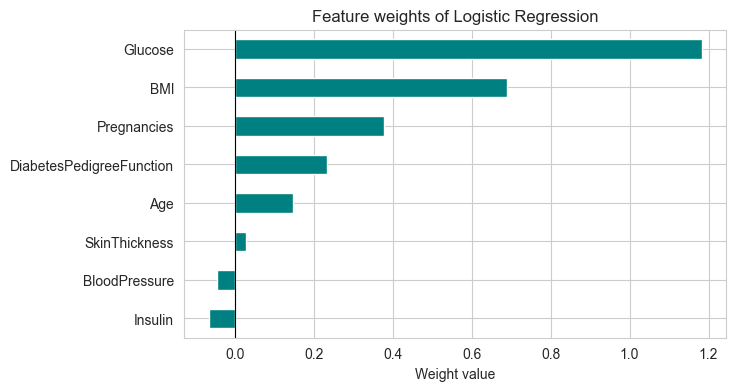

In [12]:
# Visualise feature importances (weights)
weights = pd.Series(model.coef_[0], index=X.columns).sort_values()
weights.plot(kind="barh", color="teal", figsize=(7, 4))
plt.title("Feature weights of Logistic Regression")
plt.xlabel("Weight value")
plt.axvline(0, color="k", linewidth=0.8)
plt.show()

## Step 9: Predict & Evaluate

In [13]:
# Hard predictions (0 or 1) and predicted probabilities for class 1
y_pred       = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")

Accuracy: 0.7078


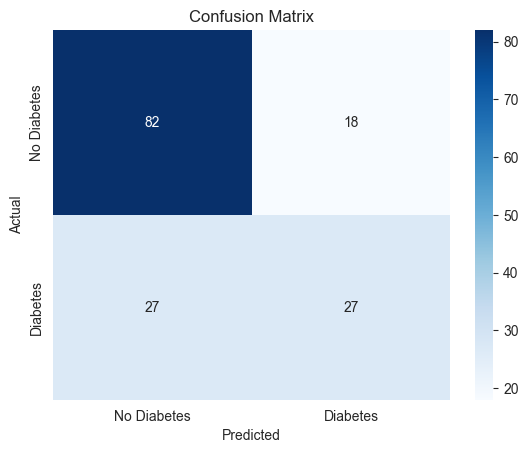

In [14]:
# Confusion matrix — visualise TP, TN, FP, FN
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["No Diabetes", "Diabetes"],
    yticklabels=["No Diabetes", "Diabetes"],
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [15]:
# Precision, Recall, F1 for both classes
print(classification_report(y_test, y_pred, target_names=["No Diabetes", "Diabetes"]))

              precision    recall  f1-score   support

 No Diabetes       0.75      0.82      0.78       100
    Diabetes       0.60      0.50      0.55        54

    accuracy                           0.71       154
   macro avg       0.68      0.66      0.67       154
weighted avg       0.70      0.71      0.70       154



### ROC Curve & AUC
**ROC** plots *True Positive Rate* vs *False Positive Rate* across all thresholds. **AUC** (area under the curve) is a single number summary — closer to **1.0 = better**, 0.5 = random guessing.

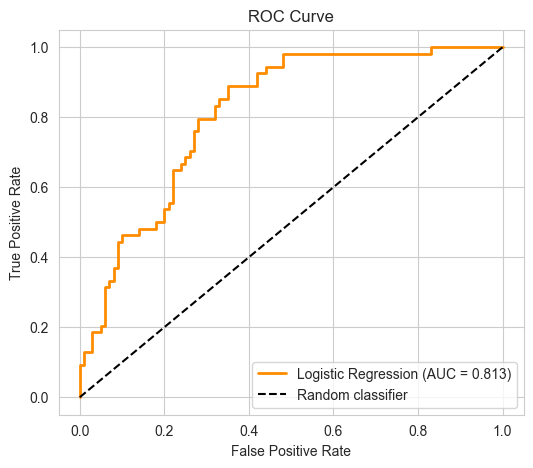

In [16]:
auc = roc_auc_score(y_test, y_pred_proba)
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.3f})", color="darkorange", linewidth=2)
plt.plot([0, 1], [0, 1], "k--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Step 10: Logistic Regression — From Scratch (NumPy)

Now let's build it ourselves to *truly* understand what `sklearn` did under the hood.

We will implement a small modular class with these methods:
- `_sigmoid(z)` — squash to probability
- `_compute_loss(y, y_hat)` — log-loss
- `fit(X, y)` — gradient descent training loop
- `predict_proba(X)` — return probabilities
- `predict(X)` — return 0/1 using a threshold

In [17]:
class LogisticRegressionScratch:
    """Binary Logistic Regression trained with batch gradient descent."""

    def __init__(self, learning_rate=0.1, n_iterations=1000, verbose=False):
        self.lr = learning_rate            # step size for gradient descent
        self.n_iters = n_iterations        # number of training iterations
        self.verbose = verbose             # print loss every 100 steps
        self.weights = None                # w vector (one entry per feature)
        self.bias = None                   # bias scalar b
        self.loss_history = []             # track loss to plot convergence

    # --- helper functions -------------------------------------------------
    @staticmethod
    def _sigmoid(z):
        # Clip z to avoid overflow in exp
        z = np.clip(z, -500, 500)
        return 1.0 / (1.0 + np.exp(-z))

    @staticmethod
    def _compute_loss(y_true, y_pred):
        # Binary cross-entropy; epsilon prevents log(0)
        eps = 1e-15
        y_pred = np.clip(y_pred, eps, 1 - eps)
        return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

    # --- training ---------------------------------------------------------
    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)
        n_samples, n_features = X.shape

        # 1) Initialise parameters to zero
        self.weights = np.zeros(n_features)
        self.bias = 0.0

        # 2) Gradient descent loop
        for i in range(self.n_iters):
            # Forward pass: linear -> sigmoid
            z = X @ self.weights + self.bias
            y_hat = self._sigmoid(z)

            # Compute gradients (vectorised)
            error = y_hat - y
            dw = (X.T @ error) / n_samples
            db = np.mean(error)

            # Update parameters
            self.weights -= self.lr * dw
            self.bias    -= self.lr * db

            # Track loss
            loss = self._compute_loss(y, y_hat)
            self.loss_history.append(loss)
            if self.verbose and i % 100 == 0:
                print(f"Iter {i:>4d} | loss = {loss:.4f}")

        return self

    # --- prediction -------------------------------------------------------
    def predict_proba(self, X):
        X = np.asarray(X, dtype=float)
        return self._sigmoid(X @ self.weights + self.bias)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

### Train our scratch model and watch the loss go down

Iter    0 | loss = 0.6931
Iter  100 | loss = 0.4657
Iter  200 | loss = 0.4560
Iter  300 | loss = 0.4539
Iter  400 | loss = 0.4533
Iter  500 | loss = 0.4531
Iter  600 | loss = 0.4531
Iter  700 | loss = 0.4531
Iter  800 | loss = 0.4531
Iter  900 | loss = 0.4531


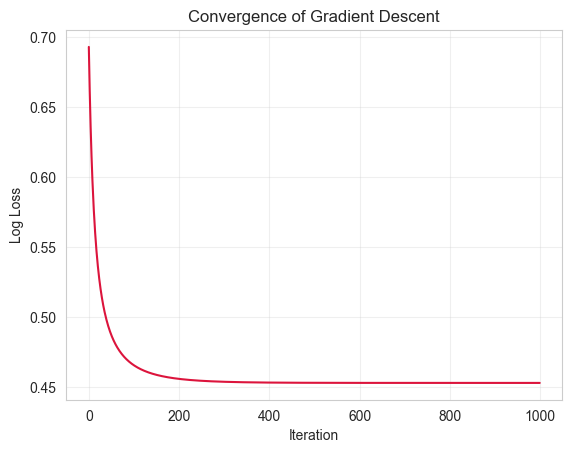

In [18]:
scratch_model = LogisticRegressionScratch(learning_rate=0.1, n_iterations=1000, verbose=True)
scratch_model.fit(X_train_scaled, y_train.values)

# Plot training loss curve
plt.plot(scratch_model.loss_history, color="crimson")
plt.xlabel("Iteration")
plt.ylabel("Log Loss")
plt.title("Convergence of Gradient Descent")
plt.grid(alpha=0.3)
plt.show()

## Step 11: Compare Scratch vs scikit-learn

In [19]:
y_pred_scratch = scratch_model.predict(X_test_scaled)
acc_scratch    = accuracy_score(y_test, y_pred_scratch)
auc_scratch    = roc_auc_score(y_test, scratch_model.predict_proba(X_test_scaled))

comparison = pd.DataFrame({
    "Model":    ["scikit-learn", "From Scratch"],
    "Accuracy": [acc, acc_scratch],
    "ROC-AUC":  [auc, auc_scratch],
})
comparison

,Model,Accuracy,ROC-AUC
0,scikit-learn,0.707792,0.812963
1,From Scratch,0.707792,0.812963


## Key Takeaways

1. **Logistic Regression** = linear model + sigmoid, trained by minimising **log-loss** with gradient descent.
2. The output is a **probability** in $(0, 1)$; we threshold it (default 0.5) to get a class label.
3. **Always scale features** when using gradient-based optimisation.
4. **Evaluate beyond accuracy** — confusion matrix, precision, recall, F1, ROC-AUC give a fuller picture, especially on imbalanced data.
5. The from-scratch model should reach **almost the same accuracy/AUC** as scikit-learn — proving our understanding of the math is correct.
